#### Run the `NicheCompass` analysis on Xenium adult healthy colon data add-on dataset (425 probes)
- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Created date:** 25th March 2024
- **Last modified dte:** 26th March 2025

#### Import Libraries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import random
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq
from matplotlib import gridspec
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import anndata as ad

from nichecompass.models import NicheCompass
from nichecompass.utils import (add_gps_from_gp_dict_to_adata,
                                compute_communication_gp_network,
                                visualize_communication_gp_network,
                                create_new_color_dict,
                                extract_gp_dict_from_mebocost_ms_interactions,
                                extract_gp_dict_from_nichenet_lrt_interactions,
                                extract_gp_dict_from_omnipath_lr_interactions,
                                filter_and_combine_gp_dict_gps_v2,
                                generate_enriched_gp_info_plots)

/home/nkise/Documents/Anya/single_cell_project/torchsparse-env/.venv/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/nkise/Documents/Anya/single_cell_project/torchsparse-env/.venv/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/nkise/Documents/Anya/single_cell_project/torchsparse-env/.venv/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/nkise/Documents/Anya/single_cell_project/torchsparse-env/.venv/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warn

In [3]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

#### Define Parameters

In [4]:
### Dataset ###
dataset = "human_intestine"
species = "human"
spatial_key = "spatial"
n_neighbors = 4

### Model ###
# AnnData Keys
counts_key = "counts"
adj_key = "spatial_connectivities"
gp_names_key = "nichecompass_gp_names"
active_gp_names_key = "nichecompass_active_gp_names"
gp_targets_mask_key = "nichecompass_gp_targets"
gp_targets_categories_mask_key = "nichecompass_gp_targets_categories"
gp_sources_mask_key = "nichecompass_gp_sources"
gp_sources_categories_mask_key = "nichecompass_gp_sources_categories"
latent_key = "nichecompass_latent"

# Architecture
conv_layer_encoder = "gcnconv" # change to "gatv2conv" if enough compute and memory
active_gp_thresh_ratio = 0.01

# Trainer
n_epochs = 400
n_epochs_all_gps = 25
lr = 0.001
lambda_edge_recon = 500000.
lambda_gene_expr_recon = 300.
lambda_l1_masked = 0. # increase if gene selection desired
lambda_l1_addon = 100.
edge_batch_size = 1024 # increase if more memory available
n_sampled_neighbors = 4
use_cuda_if_available = True

### Analysis ###
cell_type_key = "C_scANVI"
latent_leiden_resolution = 0.4
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
sample_key = "Donor_ID"
spot_size = 0.2
differential_gp_test_results_key = "nichecompass_differential_gp_test_results"

#### Run Notebook Setup

In [5]:
warnings.filterwarnings("ignore")

In [6]:
# Get time of notebook execution for timestamping saved artifacts
now = datetime.now()
current_timestamp = now.strftime("%d%m%Y_%H%M%S")

#### Configure Paths

In [7]:
# Define paths
ga_data_folder_path = "NicheCompass/gene_annotations"
gp_data_folder_path = "NicheCompass/gene_programs"
so_data_folder_path = "NicheCompass/spatial_omics"
omnipath_lr_network_file_path = f"{gp_data_folder_path}/omnipath_lr_network.csv"
collectri_tf_network_file_path = f"{gp_data_folder_path}/collectri_tf_network_{species}.csv"
nichenet_lr_network_file_path = f"{gp_data_folder_path}/nichenet_lr_network_v2_{species}.csv"
nichenet_ligand_target_matrix_file_path = f"{gp_data_folder_path}/nichenet_ligand_target_matrix_v2_{species}.csv"
mebocost_enzyme_sensor_interactions_folder_path = f"{gp_data_folder_path}/metabolite_enzyme_sensor_gps"
gene_orthologs_mapping_file_path = f"{ga_data_folder_path}/human_mouse_gene_orthologs.csv"
artifacts_folder_path = f"NicheCompass/artifacts"
model_folder_path = f"{artifacts_folder_path}/single_sample/{current_timestamp}/model"
figure_folder_path = f"{artifacts_folder_path}/single_sample/{current_timestamp}/figures"

#### Create Directories

In [8]:
import os
os.makedirs(model_folder_path, exist_ok=True)
os.makedirs(figure_folder_path, exist_ok=True)
os.makedirs(so_data_folder_path, exist_ok=True)

#### Upload the anndata file

In [9]:
adata = sc.read_h5ad('data/gut_hs_XeniumAdultColonNicheCompass_AM_21102024_150114_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 274037 × 425
    obs: 'Study_name', 'Donor_ID', 'Library_Preparation_Protocol', 'dataset', '_scvi_batch', '_scvi_labels', 'seed_labels', 'C_scANVI', 'SC_subsets', 'Cell_State', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_counts', 'REG4_score', 'gdT', 'Endothelial cells', 'latent_leiden_0.4', 'CD24_ligand_receptor_target_gene_GP', 'SLPI_ligand_receptor_target_gene_GP', 'CXCL14_ligand_receptor_target_gene_GP', 'ANPEP_ligand_receptor_target_gene_GP', 'IL1B_ligand_receptor_target_gene_GP', 'TIMP3_ligand_receptor_target_gene_GP', 'CDH1_ligand_receptor_target_gene_GP', 'TNXB_ligand_receptor_target_gene_GP', 'CLU_ligand_receptor_target_gene_GP', 'TFF1_ligand_receptor_target_gene_GP', 'CCL11_ligand_receptor_target_gene_GP', 'ROBO1_ligand_receptor_target_gene_GP', 'NRG3_ligand_receptor_

In [10]:
X_is_raw(adata)

True

In [11]:
adata.obs['C_scANVI'] = adata.obs['C_scANVI'].cat.add_categories(['Arterial capillary',
                                                                                  'Gamma delta T cells'])
adata.obs.loc[(adata.obs['C_scANVI'] == 'Adult Glia'), 'C_scANVI'] = 'Glial cells'
adata.obs.loc[(adata.obs['C_scANVI'] == 'arterial capillary'), 'C_scANVI'] = 'Arterial capillary'
adata.obs.loc[(adata.obs['C_scANVI'] == 'gdT'), 'C_scANVI'] = 'Gamma delta T cells'
adata.obs['C_scANVI'] = adata.obs['C_scANVI'].replace('Enterocyte', 'Colonocyte')
adata.obs['C_scANVI'] = adata.obs['C_scANVI'].replace('Gamma delta T cells', 'CD8 T')
adata.obs['C_scANVI'] = adata.obs['C_scANVI'].replace('Tregs', 'CD4 T')
adata.obs['C_scANVI'] = adata.obs['C_scANVI'].replace('Mesothelium', 'Fibroblasts')
adata.obs['C_scANVI'] = adata.obs['C_scANVI'].replace('Lymphatics', 'LEC')
adata.obs['C_scANVI'] = adata.obs['C_scANVI'].cat.remove_unused_categories()

In [12]:
gp_columns = [col for col in adata.obs.columns if '_GP' in col]
print(f"Removing {len(gp_columns)} columns containing '_GP'")

adata.obs = adata.obs.drop(columns=gp_columns)
print("Remaining columns:", adata.obs.shape[1])

Removing 186 columns containing '_GP'
Remaining columns: 26


### Prepare Model Training

+ Create Prior Knowledge Gene Program (GP) Mask

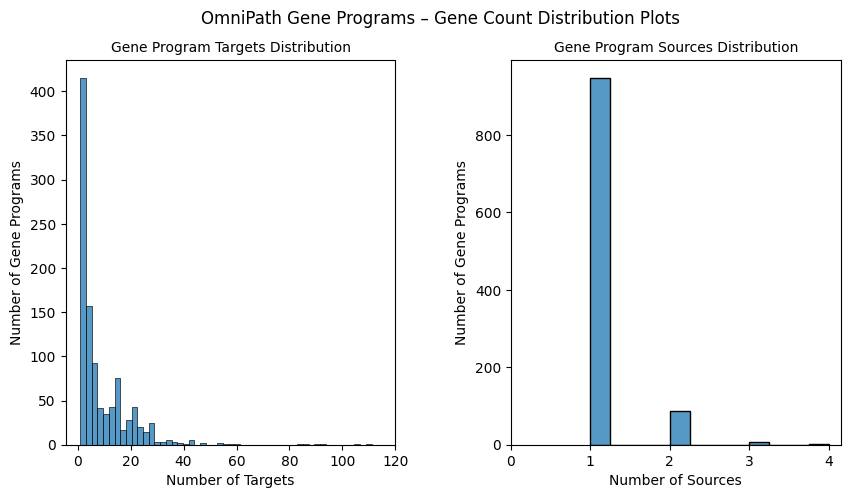

In [13]:
# Retrieve OmniPath GPs (source: ligand genes; target: receptor genes)
omnipath_gp_dict = extract_gp_dict_from_omnipath_lr_interactions(
    species=species,
    min_curation_effort=0,
    load_from_disk=False,
    save_to_disk=True,
    lr_network_file_path=omnipath_lr_network_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True,
    gp_gene_count_distributions_save_path=f"{figure_folder_path}" \
                                           "/omnipath_gp_gene_count_distributions.svg")

In [14]:
# Display example OmniPath GP
omnipath_gp_names = list(omnipath_gp_dict.keys())
random.shuffle(omnipath_gp_names)
omnipath_gp_name = omnipath_gp_names[0]
print(f"{omnipath_gp_name}: {omnipath_gp_dict[omnipath_gp_name]}")

DBH_ligand_receptor_GP: {'sources': ['DBH'], 'targets': ['ADRA1D', 'ADRA2C', 'ADRA1A', 'ADRA2A', 'GPR161', 'ADRB2', 'ADRA2B', 'ADRA1B', 'ADRB1', 'ADRB3'], 'sources_categories': ['ligand'], 'targets_categories': ['receptor', 'receptor', 'receptor', 'receptor', 'receptor', 'receptor', 'receptor', 'receptor', 'receptor', 'receptor']}


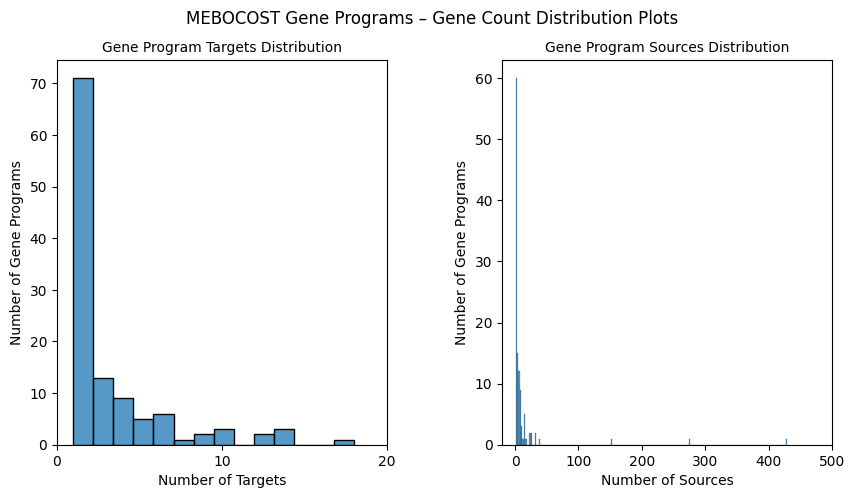

In [18]:
# Retrieve MEBOCOST GPs (source: enzyme genes; target: sensor genes)
mebocost_gp_dict = extract_gp_dict_from_mebocost_ms_interactions(
    dir_path=mebocost_enzyme_sensor_interactions_folder_path,
    species=species,
    plot_gp_gene_count_distributions=True)

In [19]:
# Display example MEBOCOST GP
mebocost_gp_names = list(mebocost_gp_dict.keys())
random.shuffle(mebocost_gp_names)
mebocost_gp_name = mebocost_gp_names[0]
print(f"{mebocost_gp_name}: {mebocost_gp_dict[mebocost_gp_name]}")

Thyroxine_metabolite_enzyme_sensor_GP: {'sources': ['DIO1', 'DIO2', 'DIO3', 'TPO'], 'sources_categories': ['enzyme', 'enzyme', 'enzyme', 'enzyme'], 'targets': ['SLC16A2', 'THRA', 'THRB'], 'targets_categories': ['sensor', 'sensor', 'sensor']}


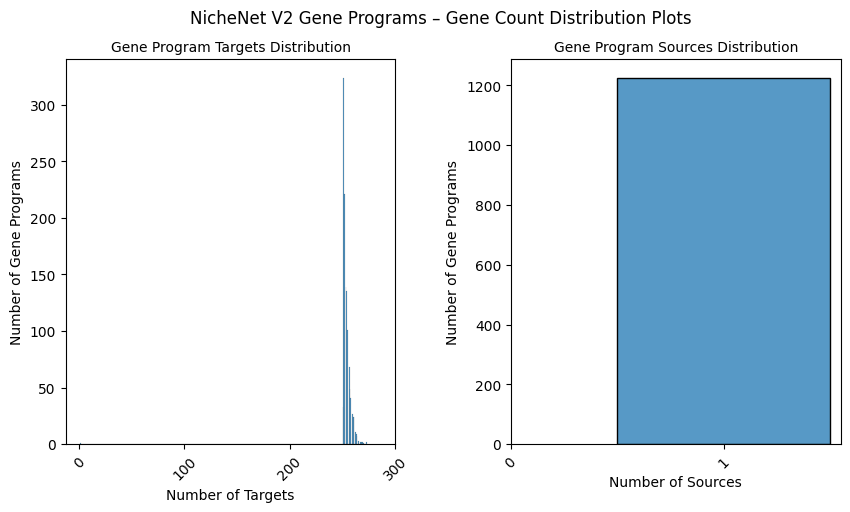

In [20]:
# Retrieve NicheNet GPs (source: ligand genes; target: receptor genes, target genes)
nichenet_gp_dict = extract_gp_dict_from_nichenet_lrt_interactions(
    species=species,
    version="v2",
    keep_target_genes_ratio=1.,
    max_n_target_genes_per_gp=250,
    load_from_disk=False,
    save_to_disk=True,
    lr_network_file_path=nichenet_lr_network_file_path,
    ligand_target_matrix_file_path=nichenet_ligand_target_matrix_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True)

In [21]:
# Display example NicheNet GP
nichenet_gp_names = list(nichenet_gp_dict.keys())
random.shuffle(nichenet_gp_names)
nichenet_gp_name = nichenet_gp_names[0]
print(f"{nichenet_gp_name}: {nichenet_gp_dict[nichenet_gp_name]}")

FGF2_ligand_receptor_target_gene_GP: {'sources': ['FGF2'], 'targets': ['FGFR2', 'FGFR4', 'FGFR3', 'SDC1', 'FGFR1', 'CD44', 'SDC3', 'SDC4', 'GPC4', 'SDC2', 'FGFRL1', 'NRP1', 'ACKR3', 'ACSL4', 'ACTC1', 'ADAMTS5', 'AK5', 'AKAP13', 'AKR1C3', 'ALDH1A1', 'ALDOC', 'ANPEP', 'ANXA3', 'AQP3', 'ARHGDIB', 'ASF1B', 'ASPM', 'ASS1', 'ATAD2', 'ATF3', 'B3GALNT1', 'B3GALT2', 'BAMBI', 'BEX1', 'BHLHE40', 'BHLHE41', 'BTN3A1', 'C1GALT1', 'CAPG', 'CAV1', 'CCL2', 'CCNA2', 'CCND1', 'CCNE1', 'CDC42EP3', 'CDC45', 'CDCP1', 'CDKN1A', 'CEBPB', 'CEBPD', 'CEMIP', 'CENPE', 'CENPM', 'CEP55', 'CHAC1', 'CHI3L1', 'CHIC2', 'CIT', 'CITED2', 'CKAP2', 'CLIC3', 'CLIP4', 'COL11A1', 'COL1A1', 'COL4A1', 'COL4A2', 'COLEC12', 'COQ10B', 'CORO2B', 'CPA4', 'CRIP2', 'CSRP2', 'CXCL12', 'CXCL8', 'CYP1B1', 'DAB2', 'DACT1', 'DAPK1', 'DCBLD2', 'DDIT3', 'DHRS3', 'DIRAS3', 'DOCK4', 'DTL', 'DUSP4', 'DUSP5', 'DUSP6', 'E2F8', 'EDN1', 'EGR1', 'EGR3', 'ELK3', 'ENPP1', 'EPAS1', 'EPHB2', 'ESM1', 'ESPL1', 'ETS2', 'EXO1', 'F2RL1', 'F3', 'FAXDC2', 'FGF

In [22]:
# Add GPs into one combined dictionary for model training
combined_gp_dict = dict(omnipath_gp_dict)
combined_gp_dict.update(mebocost_gp_dict)
combined_gp_dict.update(nichenet_gp_dict)

In [23]:
gp_dicts = [omnipath_gp_dict, nichenet_gp_dict, mebocost_gp_dict]
combined_gp_dict = filter_and_combine_gp_dict_gps_v2(
    gp_dicts,
    verbose=True)

print(f"Number of gene programs after filtering and combining: "
      f"{len(combined_gp_dict)}.")

Combining ACE2_ligand_receptor_GP and ACE2_ligand_receptor_target_gene_GP.
Combining ADAM11_ligand_receptor_GP and ADAM11_ligand_receptor_target_gene_GP.
Combining ADAMTS3_ligand_receptor_GP and ADAMTS3_ligand_receptor_target_gene_GP.
Combining ADCYAP1_ligand_receptor_GP and ADCYAP1_ligand_receptor_target_gene_GP.
Combining ADGRE5_ligand_receptor_GP and ADGRE5_ligand_receptor_target_gene_GP.
Combining ADIPOQ_ligand_receptor_GP and ADIPOQ_ligand_receptor_target_gene_GP.
Combining ADM_ligand_receptor_GP and ADM_ligand_receptor_target_gene_GP.
Combining ADM2_ligand_receptor_GP and ADM2_ligand_receptor_target_gene_GP.
Combining AGRP_ligand_receptor_GP and AGRP_ligand_receptor_target_gene_GP.
Combining AGT_ligand_receptor_GP and AGT_ligand_receptor_target_gene_GP.
Combining ALCAM_ligand_receptor_GP and ALCAM_ligand_receptor_target_gene_GP.
Combining ALKAL1_ligand_receptor_GP and ALKAL1_ligand_receptor_target_gene_GP.
Combining ALKAL2_ligand_receptor_GP and ALKAL2_ligand_receptor_target_gene

#### Compute Spatial Neighbor Graph for adata

In [24]:
# Compute spatial neighborhood
sq.gr.spatial_neighbors(adata,
                        coord_type="generic",
                        spatial_key=spatial_key,
                        n_neighs=n_neighbors)

# Make adjacency matrix symmetric
adata.obsp[adj_key] = (
    adata.obsp[adj_key].maximum(
        adata.obsp[adj_key].T))

+ Add GP Mask to Data

In [25]:
# Add the GP dictionary as binary masks to the adata
add_gps_from_gp_dict_to_adata(
    gp_dict=combined_gp_dict,
    adata=adata,
    gp_targets_mask_key=gp_targets_mask_key,
    gp_targets_categories_mask_key=gp_targets_categories_mask_key,
    gp_sources_mask_key=gp_sources_mask_key,
    gp_sources_categories_mask_key=gp_sources_categories_mask_key,
    gp_names_key=gp_names_key,
    min_genes_per_gp=2,
    min_source_genes_per_gp=1,
    min_target_genes_per_gp=1,
    max_genes_per_gp=None,
    max_source_genes_per_gp=None,
    max_target_genes_per_gp=None)

+ Explore Data

In [26]:
cell_type_colors = create_new_color_dict(
    adata=adata,
    cat_key=cell_type_key)

In [28]:
adata.layers['counts'] = adata.X.copy()

In [29]:
print(f"Number of nodes (observations): {adata.layers['counts'].shape[0]}")
print(f"Number of node features (genes): {adata.layers['counts'].shape[1]}")

Number of nodes (observations): 274037
Number of node features (genes): 425


#### Train Model

+ Initialize, Train & Save Model

In [30]:
model = NicheCompass(adata,
                     counts_key=counts_key,
                     adj_key=adj_key,
                     gp_names_key=gp_names_key,
                     active_gp_names_key=active_gp_names_key,
                     gp_targets_mask_key=gp_targets_mask_key,
                     gp_targets_categories_mask_key=gp_targets_categories_mask_key,
                     gp_sources_mask_key=gp_sources_mask_key,
                     gp_sources_categories_mask_key=gp_sources_categories_mask_key,
                     latent_key=latent_key,
                     conv_layer_encoder=conv_layer_encoder,
                     active_gp_thresh_ratio=active_gp_thresh_ratio)

--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 425, n_cat_covariates_embed_input: 0, n_hidden: 211, n_latent: 111, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 111, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 425
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 111, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 425


* Train model

In [31]:
model.train(n_epochs=n_epochs,
            n_epochs_all_gps=n_epochs_all_gps,
            lr=lr,
            lambda_edge_recon=lambda_edge_recon,
            lambda_gene_expr_recon=lambda_gene_expr_recon,
            lambda_l1_masked=lambda_l1_masked,
            edge_batch_size=edge_batch_size,
            n_sampled_neighbors=n_sampled_neighbors,
            use_cuda_if_available=use_cuda_if_available,
            verbose=False)


--- INITIALIZING TRAINER ---
Number of training nodes: 246633
Number of validation nodes: 27404
Number of training edges: 583362
Number of validation edges: 64818
Edge batch size: 1024
Node batch size: None

--- MODEL TRAINING ---
Epoch 1/400 |--------------------| 0.2% train_global_loss: 391442.6190; train_optim_loss: 391442.6190; val_global_loss: 372163.6343; val_optim_loss: 372163.6343
Epoch 2/400 |--------------------| 0.5% train_global_loss: 364649.6201; train_optim_loss: 364649.6201; val_global_loss: 364122.7402; val_optim_loss: 364122.7402
Epoch 3/400 |--------------------| 0.8% train_global_loss: 359342.5414; train_optim_loss: 359342.5414; val_global_loss: 360504.3345; val_optim_loss: 360504.3345
Epoch 4/400 |--------------------| 1.0% train_global_loss: 355846.8373; train_optim_loss: 355846.8373; val_global_loss: 357836.5098; val_optim_loss: 357836.5098
Epoch 5/400 |--------------------| 1.2% train_global_loss: 353598.6487; train_optim_loss: 353598.6487; val_global_loss: 3561

+ Compute UMAP

In [32]:
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)

sc.tl.umap(model.adata,
           neighbors_key=latent_key)

* Save trained model

In [33]:
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="NicheCompass/adata.h5ad")